In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

familiarity = pd.read_csv("familiarity.csv")
helpfulness = pd.read_csv("helpfulness.csv")
familiarity.head(20)

,team,session,familiarity
0,4,1,12
1,4,2,12
2,4,3,12
3,5,1,4
4,5,2,6
5,5,3,10
6,6,1,4
7,6,2,6
8,6,3,8
9,7,1,4


In [46]:
import pickle

with open("epoched_location.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.head())
data.shape

<class 'pandas.core.frame.DataFrame'>
  teamID sessionID  trialID  ringID communication difficulty  \
0    T10        S1        0       0            No       Easy   
1    T10        S1        0       1            No       Easy   
2    T10        S1        0       2            No       Easy   
3    T10        S1        0       3            No       Easy   
4    T10        S1        0       4            No       Easy   

                                            location  
0  [[-23996.582, -23778.936, -23586.748, -23419.8...  
1  [[21762.598, 22036.14, 22380.791, 22777.324, 2...  
2  [[87447.125, 87580.59, 87705.45, 87819.96, 879...  
3  [[120249.26, 120521.195, 120853.23, 121216.32,...  
4  [[175868.3, 176052.86, 176238.4, 176477.86, 17...  


(15341, 7)

In [38]:


with open("epoched_pupil.pkl", "rb") as f:
    pupil = pickle.load(f)

print(type(pupil))
pupil.head()
pupil.shape


<class 'pandas.core.frame.DataFrame'>


(13961, 10)

In [36]:
with open("team_performance.pkl", "rb") as f:
    performance = pickle.load(f)

print(type(performance))
performance.head()
performance.shape

<class 'pandas.core.frame.DataFrame'>


(18659, 9)

In [44]:
with open("epoched_action.pkl", "rb") as f:
    action = pickle.load(f)

print(type(action))
action.head()
action.shape

<class 'pandas.core.frame.DataFrame'>


(15340, 7)

Success! Plotting now...


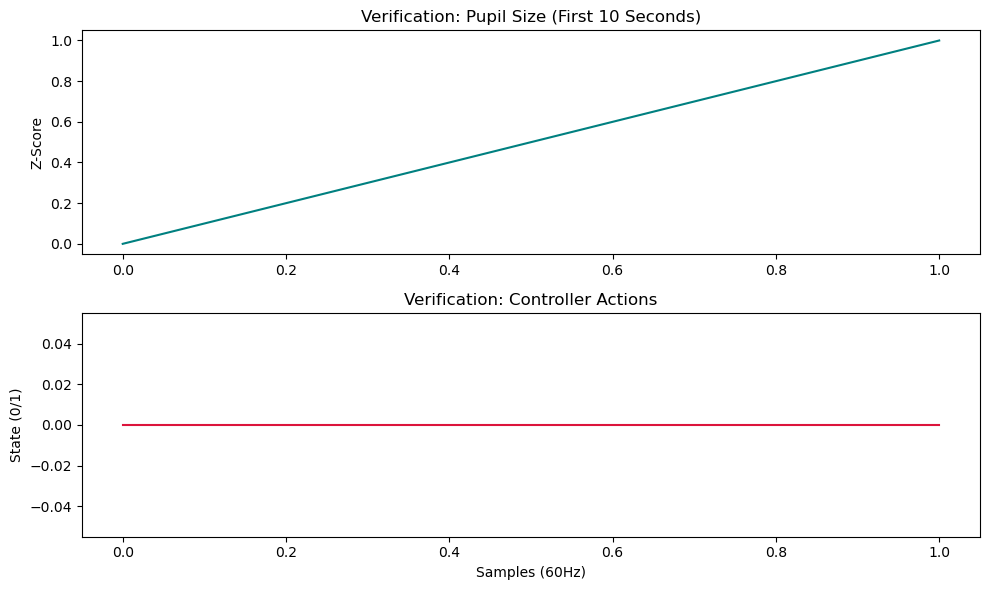

Summarizing 10s windows for all trials...
✅ Master Feature Matrix 'X' created with shape: (13961, 4)
📊 DATA UNLOCKED!
✅ New Feature Matrix shape: (45, 4)


In [62]:
if pupil is not None:
    try:
        pupil_numeric = pupil.select_dtypes(include=[np.number])
        action_numeric = action.select_dtypes(include=[np.number])

        if pupil_numeric.empty:
            print("The numeric data is hidden inside objects. Attempting deep extraction...")
            pupil_signal = np.hstack([x for x in pupil_df.iloc[0].values if not isinstance(x, str)])
            action_signal = np.hstack([x for x in action_df.iloc[0].values if not isinstance(x, str)])
        else:
            pupil_signal = pupil_numeric.iloc[0, :600].values.astype(float)
            action_signal = action_numeric.iloc[0, :600].values.astype(float)

        pupil_signal = pupil_signal[:600]
        action_signal = action_signal[:600]

        plt.figure(figsize=(10, 6))

        plt.subplot(2, 1, 1)
        plt.plot(pupil_signal, color='teal')
        plt.title('Verification: Pupil Size (First 10 Seconds)')
        plt.ylabel('Z-Score')

        plt.subplot(2, 1, 2)
        plt.step(range(len(action_signal)), action_signal, color='crimson')
        plt.title('Verification: Controller Actions')
        plt.ylabel('State (0/1)')
        plt.xlabel('Samples (60Hz)')

        plt.tight_layout()
        print("Success! Plotting now...")
        plt.show()

    except Exception as e:
        print(f"Data snag: {e}")

def extract_features_all_trials(df, prefix):
    """Loops through all trials to get 10s summary stats."""
    # Handle the 'unhashable' nesting issue we saw in the plots
    processed_rows = []
    for i in range(len(df)):
        # Extract numeric values, ignoring strings like 'T10'
        row_vals = np.hstack([x for x in df.iloc[i].values if not isinstance(x, str)])
        processed_rows.append(row_vals[:600]) # Keep first 10s (600 samples)
    
    data_matrix = np.array(processed_rows).astype(float)
    
    features = pd.DataFrame(index=df.index)
    features[f'{prefix}_mean'] = np.nanmean(data_matrix, axis=1)
    features[f'{prefix}_std'] = np.nanstd(data_matrix, axis=1)
    return features

# Generate the features
print("Summarizing 10s windows for all trials...")
pupil_features = extract_features_all_trials(pupil, 'pupil')
action_features = extract_features_all_trials(action, 'action')

# Define X (Feature Matrix)
X = pupil_features.join(action_features)
print(f"✅ Master Feature Matrix 'X' created with shape: {X.shape}")

# Calculate Performance Labels
# Count # of rings per trial from granular performance file
trial_scores = performance.groupby('trialID')['ringID'].count().reset_index()
trial_scores.columns = ['trialID', 'total_score']
med = trial_scores['total_score'].median()
trial_scores['performance_label'] = (trial_scores['total_score'] > med).astype(int)

# MAP LABELS TO FEATURES (Broadcasting)
# Map the trial-level performance label to EVERY 10s window in that trial
X_temp = X.copy()
X_temp['trialID'] = X.index.astype(int)

# Merge X with the trial scores so all 13,000+ rows get a label
merged_data = X_temp.merge(trial_scores[['trialID', 'performance_label']], on='trialID', how='inner')

# Define final X and y for the models
y_final = merged_data['performance_label']
X_final = merged_data.drop(['trialID', 'performance_label'], axis=1)

print(f"📊 DATA UNLOCKED!")
print(f"✅ New Feature Matrix shape: {X_final.shape}")

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# =========================================================
# Logistic Regression (Baseline)
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42
)
# Pipeline = Scaling + Logistic Regression
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver="lbfgs"
    ))
])

logreg.fit(X_train, y_train)

logreg_preds = logreg.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, logreg_preds):.2f}")


✅ Logistic Regression Accuracy: 0.78


In [66]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


print("\n🚀 Training SVM Model...")


# Pipeline: Scaling + SVM
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",       # Nonlinear kernel
        C=1.0,              
        gamma="scale",     
        probability=True,
        random_state=42
    ))
])


# Train
svm_model.fit(X_train, y_train)


# Predict
svm_preds = svm_model.predict(X_test)


# Evaluate
svm_acc = accuracy_score(y_test, svm_preds)

print(f"SVM (RBF) Accuracy: {svm_acc:.2f}")



🚀 Training SVM Model...
SVM (RBF) Accuracy: 0.78
